# 06. RAG 벡터 인덱스 구축

train 리뷰 2,000건을 샘플링해 임베딩(`all-MiniLM-L6-v2`) 후 Chroma(`chroma_store/`)에 저장한다.

In [4]:
import sys
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import pandas as pd
from src.config import DATA_DIR, VECTOR_DIR, OUTPUT_DIR, RANDOM_SEED
from src.rag.index import build_index

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA_DIR / "train.csv").sample(2000, random_state=RANDOM_SEED)
build_index(df["text"].tolist(), VECTOR_DIR)
print(f"indexed {len(df)} reviews into {VECTOR_DIR}")

indexed 2000 reviews into /Users/gomuseo/Desktop/Python/review-check/chroma_store


In [5]:
# 검색 스모크 테스트
from src.rag.index import get_collection
col = get_collection(VECTOR_DIR)
res = col.query(query_texts=["is this game fun?"], n_results=3)
for doc in res["documents"][0]:
    print("-", doc[:100])

- THIS GAME IS SO FUN
- THE GAME IS FUN . THAT ALL THATS HOW FUN IT IS
- This game is soo fun!!!


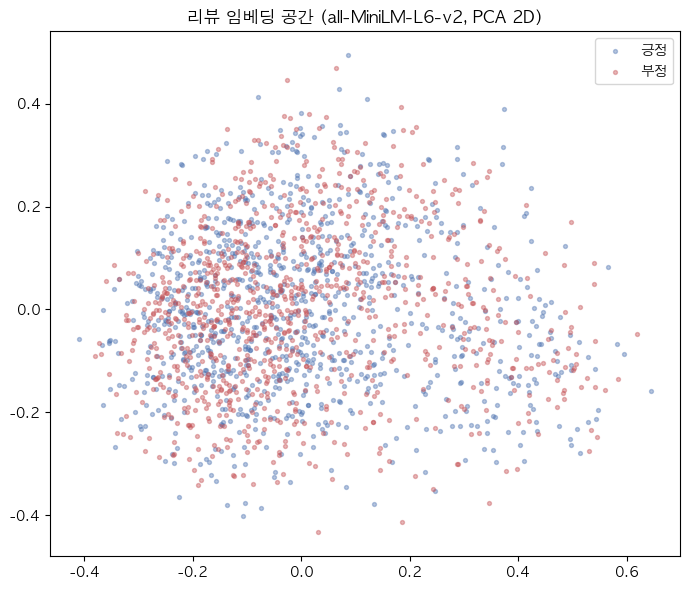

In [6]:
# 임베딩 공간 시각화: PCA 2D, 리뷰 감성 라벨로 색상 구분
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False

got = col.get(include=["embeddings"])
order = np.argsort([int(i) for i in got["ids"]])  # id 순서를 df 순서와 맞춤
embs = np.array(got["embeddings"])[order]
labels = df["label"].to_numpy()

pts = PCA(n_components=2, random_state=42).fit_transform(embs)

fig, ax = plt.subplots(figsize=(7, 6))
for lab, name, color in [(1, "긍정", "#4c72b0"), (0, "부정", "#c44e52")]:
    m = labels == lab
    ax.scatter(pts[m, 0], pts[m, 1], s=8, alpha=0.4, label=name, color=color)
ax.set_title("리뷰 임베딩 공간 (all-MiniLM-L6-v2, PCA 2D)")
ax.legend()
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "06_embedding_pca.png", dpi=150, bbox_inches="tight")
plt.show()